# Imports

In [1]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Varying alpha

## load rebb data

In [2]:
root = '/data/home/Licheng/workspace/TSF-PCA/results_PCA/finetune_rebb'
exp_dirs = os.listdir(root)
exp_dirs = [os.path.join(root, exp_dir) for exp_dir in exp_dirs]

params = ['model', 'seq_len', 'pred_len', 'data_id', 'learning_rate', 'rec_lambda', 'auxi_lambda', 'pca_dim', 'reinit', 'use_weights', 'rank_ratio', 'auxi_loss', 'batch_size', 'auxi_type', 'auxi_mode', 'lradj', 'patience', 'train_epochs']
metric_names = ['mse', 'mae']

df_rebb = []
for exp_dir in exp_dirs:
    runned, setting_dir = exist_metric(exp_dir)
    if not runned:
        continue

    config = load_yaml_as_df(os.path.join(setting_dir, 'config.yaml'))
    metric = load_npy(os.path.join(setting_dir, 'metrics.npy'))
    result = config[params]
    result.loc[:, metric_names] = metric[1], metric[0]
    result.loc[:, ['exp_dir']] = exp_dir
    df_rebb.append(result)

df_rebb = pd.concat(df_rebb, ignore_index=True)
df_rebb.sort_values(by=['model', 'data_id', 'pred_len'], inplace=True)

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
# df_rebb.to_csv(f"{save_root}/finetune_all_results.csv", index=False)

df_rebb.head(4)

,model,seq_len,pred_len,data_id,learning_rate,rec_lambda,auxi_lambda,pca_dim,reinit,use_weights,rank_ratio,auxi_loss,batch_size,auxi_type,auxi_mode,lradj,patience,train_epochs,mse,mae,exp_dir
9,FreTS,96,96,Weather_PCA,0.0070,0.3,0.7,T,1,0,1.0,MAE,16,pca,basis,type3,10,10,0.184741,0.238842,/data/home/Licheng/workspace/TSF-PCA/results_P...
11,FreTS,96,96,Weather_PCA,0.0050,0.0,1.0,T,1,0,1.0,MAE,32,pca,basis,type3,10,10,0.184611,0.229810,/data/home/Licheng/workspace/TSF-PCA/results_P...
17,FreTS,96,96,Weather_PCA,0.0095,0.3,0.7,T,1,0,1.0,MAE,16,pca,basis,type3,10,10,0.185726,0.232188,/data/home/Licheng/workspace/TSF-PCA/results_P...
23,FreTS,96,96,Weather_PCA,0.0065,0.0,1.0,T,1,0,1.0,MAE,16,pca,basis,type3,10,10,0.178406,0.221951,/data/home/Licheng/workspace/TSF-PCA/results_P...


## load data

In [3]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

baselines = pd.read_csv(f'{save_root}/baselines_params.csv')
finetunes_all = pd.read_csv(f'{save_root}/finetune_all_results.csv')

base = baselines.copy()
base = base[
    # ((base.data_id == 'ETTh1') & (base.model == 'Fredformer')) |
    # ((base.data_id == 'ETTh2') & (base.model == 'Fredformer')) |
    # ((base.data_id == 'ETTm1') & (base.model == 'Fredformer')) |
    # ((base.data_id == 'ETTm2') & (base.model == 'Fredformer')) |
    # ((base.data_id == 'ECL') & (base.model == 'iTransformer')) |
    ((base.data_id == 'Weather') & (base.model == 'FreTS'))
]
base['alpha'] = 0.0

hpa = finetunes_all.copy()
df_rebb_ = df_rebb[hpa.columns]
# df_rebb_ = df_rebb_[df_rebb_.auxi_lambda.isin([1.0])]
hpa = pd.concat([hpa, df_rebb_], ignore_index=True)
hpa = hpa[
    (hpa.pca_dim == 'T') &
    (hpa.use_weights == 0) &
    (hpa.auxi_loss == 'MAE') &
    (hpa.reinit == 1) &
    (hpa.seq_len == 96)
]
hpa = hpa[
    # ((hpa.data_id == 'ETTh1_PCA') & (hpa.model == 'Fredformer')) |
    # ((hpa.data_id == 'ETTh2_PCA') & (hpa.model == 'Fredformer')) |
    # ((hpa.data_id == 'ETTm1_PCA') & (hpa.model == 'Fredformer')) |
    # ((hpa.data_id == 'ETTm2_PCA') & (hpa.model == 'Fredformer')) |
    # ((hpa.data_id == 'ECL_PCA') & (hpa.model == 'iTransformer')) |
    ((hpa.data_id == 'Weather_PCA') & (hpa.model == 'FreTS'))
]
hpa.rename(columns={'auxi_lambda': 'alpha'}, inplace=True)
hpa.drop(columns=['rec_lambda'], inplace=True)


In [11]:
hpa.learning_rate.unique()
hpa.batch_size.unique()

array([ 32, 128, 256,  64])

## preprocess all

In [4]:
df2 = hpa.copy()

df2 = df2[
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 0.7) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    # ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 0.9) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 0.6) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 96) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 0.5) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 192) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 336) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 0.3) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 96) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 192) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 336) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 1.0) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    
    # ((df2.rank_ratio == 0.1) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.1) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
    # ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
    ((df2.rank_ratio == 1.0) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 1.0) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 1.0) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 1.0) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
]
# 按data去给一个alpha


min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'alpha'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('_PCA', ''))

df3 = base.copy()
df3['rank_ratio'] = 1.0

columns = ['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae', 'rank_ratio', 'learning_rate']
df3 = df3[columns]
df2 = df2[columns]

df_alpha = pd.concat([df3, df2], axis=0)

dst_order = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2', 'ECL', 'Weather']
df_alpha['data_id'] = pd.Categorical(df_alpha['data_id'], categories=dst_order, ordered=True)

df_alpha['alpha'] = df_alpha['alpha'].astype(float)
df_alpha.dropna(inplace=True, thresh=6)

df_alpha.sort_values(by=['data_id', 'alpha', 'pred_len'], inplace=True)

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
columns = ['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae', 'learning_rate']
# df_alpha[columns].to_csv(f'{save_root}/hyper_study_alpha.csv', index=False)

df_alpha.head(10)

,model,data_id,pred_len,alpha,mse,mae,rank_ratio,learning_rate
176,FreTS,Weather,96,0.0,0.173683,0.227737,1.0,0.0005
177,FreTS,Weather,192,0.0,0.212846,0.266092,1.0,0.0005
178,FreTS,Weather,336,0.0,0.270492,0.315915,1.0,0.0005
179,FreTS,Weather,720,0.0,0.337221,0.362299,1.0,0.0005
16973,FreTS,Weather,96,0.1,0.173399,0.227905,1.0,0.0005
18548,FreTS,Weather,192,0.1,0.212942,0.264194,1.0,0.0005
19364,FreTS,Weather,336,0.1,0.263854,0.307382,1.0,0.0005
21334,FreTS,Weather,720,0.1,0.335304,0.358654,1.0,0.0005
17516,FreTS,Weather,96,0.2,0.172087,0.225784,1.0,0.0005
18829,FreTS,Weather,192,0.2,0.212116,0.261942,1.0,0.0005


In [5]:
import pandas as pd

df = df_alpha.copy()


avg_df = df.groupby('alpha', as_index=False)[['mse', 'mae']].mean()
avg_df['pred_len'] = 'avg'

# 2. 合并到原数据
df = pd.concat([df, avg_df], ignore_index=True)

# 3. 按alpha, pl排序（可选）
df = df.sort_values(['alpha', 'pred_len'], key=lambda x: x if x.name != 'pred_len' else x.replace('avg', 'zavg'))

# 4. 如果需要，可以reset_index(drop=True)
df = df.reset_index(drop=True)

df.to_csv(f'{save_root}/hyper_alpha_weather_full.csv', index=False)

df = df.set_index('alpha')

# 第二步，pivot
table = df.pivot(columns='pred_len')[['mse', 'mae']]

# 第三步，如果你需要把列的顺序调整成 (pl, mse/mae) 两层，可以 reorder_levels
table.columns = table.columns.swaplevel(0, 1)
table = table.sort_index(axis=1, level=0)

# 或者用 pivot_table 实现（效果类似）
table = pd.pivot_table(df.reset_index(), index='alpha', columns='pred_len', values=['mse', 'mae'])

# 如果想把列的顺序换成 (pl, mse/mae) 而不是 (mse/mae, pl)
table = table.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)

save_dir = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
# table.to_csv(f'{save_dir}/hyper_alpha_weather.csv')
table

pred_len        96                 192                 336            \
               mae       mse       mae       mse       mae       mse   
alpha                                                                  
0.0       0.227737  0.173683  0.266092  0.212846  0.315915  0.270492   
0.1       0.227905  0.173399  0.264194  0.212942  0.307382  0.263854   
0.2       0.225784  0.172087  0.261942  0.212116  0.303603  0.262752   
0.3       0.226399  0.172666  0.264440  0.213444  0.306551  0.263615   
0.4       0.224552  0.171959  0.266249  0.212899  0.307178  0.264278   
0.5       0.224918  0.172789  0.263727  0.213222  0.303336  0.262898   
0.6       0.223452  0.172114  0.265305  0.212843  0.308431  0.263734   
0.7       0.219851  0.167941  0.262094  0.209470  0.299942  0.255742   
0.8       0.219771  0.167066  0.260859  0.207935  0.302698  0.258003   
0.9       0.216796  0.167290  0.256985  0.206980  0.303262  0.261268   
1.0       0.216483  0.168962  0.258139  0.212856  0.301691  0.264035   

pred_len       720                 avg            
               mae       mse       mae       mse  
alpha                                             
0.0       0.362299  0.337221  0.293011  0.248560  
0.1       0.358654  0.335304  0.289534  0.246375  
0.2       0.360725  0.334733  0.288013  0.245422  
0.3       0.360364  0.336654  0.289439  0.246595  
0.4       0.353109  0.331495  0.287772  0.245158  
0.5       0.356222  0.332544  0.287051  0.245363  
0.6       0.354937  0.332130  0.288031  0.245206  
0.7       0.360701  0.330934  0.285647  0.241022  
0.8       0.362061  0.332297  0.286347  0.241325  
0.9       0.353666  0.332803  0.282677  0.242085  
1.0       0.350836  0.330801  0.281787  0.244163

In [ ]:
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 96) & (hpa.rank_ratio == 0.1)].sort_values(by=['mse'], ascending=True).head(5)
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 192) & (hpa.rank_ratio == 0.1)].sort_values(by=['mse'], ascending=True).head(5)
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 336) & (hpa.rank_ratio == 0.3)].sort_values(by=['mse'], ascending=True).head(5)
hpa[(hpa['data_id'] == 'Weather_PCA') & (hpa['alpha'] == 1.0) & (hpa.pred_len == 720) & (hpa.rank_ratio == 0.3)].sort_values(by=['mse'], ascending=True).head(5)

## plot all

5 0.022
5 0.018
5 0.004
5 0.006
5 0.018


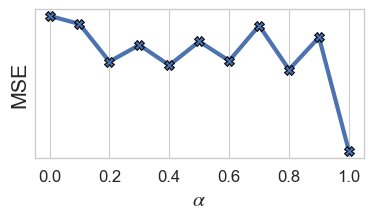

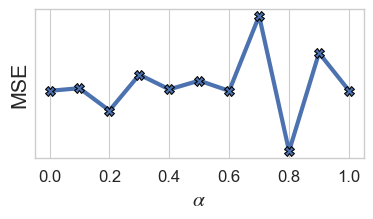

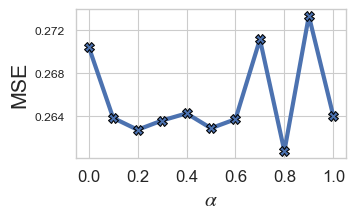

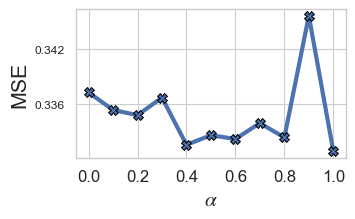

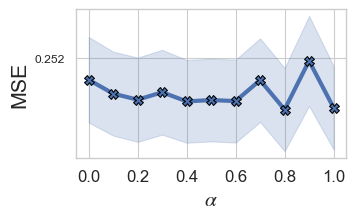

In [6]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'upper right'  # 这里可以根据图的实际情况调节。
    labelsize = 12
    ci = 15
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=100, figsize=(4, 2.5))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='value', hue='metric', data=df, style='metric', errorbar=errorbar, markers=['X'], linewidth=3, markersize=7, markeredgecolor='k', palette=palette[1:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))  # 小数点后3位数间隔。
    leg = plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    leg.remove()
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize, axis='x')
    print(len(str(ypad1)), str(ypad1))
    if len(str(ypad1)) >= 5:  # 0.001
        plt.tick_params(labelsize=8.7, axis='y')
    else:
        plt.tick_params(labelsize=labelsize, axis='y')
    if ytick1:
        plt.yticks(ytick1)
    plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)

dfp = df_alpha.copy()
# dfp = dfp[dfp.pred_len.isin([192, 336])]

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/hyper_study_all_weather'
os.makedirs(save_dir, exist_ok=True)

data_id = 'Weather'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.022)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.018)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.004)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.006)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.018)

In [ ]:
dfp = df_alpha.copy()
dfp['lambda'] = 1 - dfp['alpha']
dfp[(dfp.data_id == 'ECL') & (dfp.pred_len == 720)]

# Varying rank ratio

## load data

In [ ]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

finetunes_all = pd.read_csv(f'{save_root}/finetune_all_results.csv')

hpr = finetunes_all.copy()
hpr = hpr[
    (hpr.pca_dim == 'T') &
    (hpr.use_weights == 0) &
    (hpr.auxi_loss == 'MAE') &
    (hpr.reinit == 1) &
    (hpr.seq_len == 96)
]
hpr = hpr[
    ((hpr.data_id == 'ETTh1_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ETTh2_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ETTm1_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ETTm2_PCA') & (hpr.model == 'Fredformer')) |
    ((hpr.data_id == 'ECL_PCA') & (hpr.model == 'iTransformer')) |
    ((hpr.data_id == 'Weather_PCA') & (hpr.model == 'FreTS'))
]
hpr.rename(columns={'auxi_lambda': 'alpha'}, inplace=True)
hpr.drop(columns=['rec_lambda'], inplace=True)


## preprocess main

In [ ]:
df2 = hpr.copy()

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'rank_ratio'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('_PCA', ''))

columns = ['model', 'data_id', 'pred_len', 'rank_ratio', 'mse', 'mae']
df2 = df2[columns]

df_rank = df2.copy()

dst_order = ['ECL', 'Weather']
df_rank['data_id'] = pd.Categorical(df_rank['data_id'], categories=dst_order, ordered=True)

df_rank['rank_ratio'] = df_rank['rank_ratio'].astype(float)

df_rank.sort_values(by=['model', 'data_id', 'rank_ratio', 'pred_len'], inplace=True)
df_rank.head(10)

## plot main

In [ ]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'center right'  # 这里可以根据图的实际情况调节。
    labelsize = 12

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='mse', hue='pred_len', data=df, style='pred_len', errorbar=('ci', 95), markers=['s', 'o'], linewidth=3, markersize=8, markeredgecolor='k', palette=palette[:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))  # 小数点后3位数间隔。
    plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize)
    if ytick1:
        plt.yticks(ytick1)
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}_MSE.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


    f = plt.figure(dpi=400, figsize=(4, 3))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='mae', hue='pred_len', data=df, style='pred_len', errorbar=('ci', 95), markers=['s', 'o'], linewidth=3, markersize=8, markeredgecolor='k', palette=palette[:2])
    ax = plt.gca()
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))  # 小数点后3位数间隔。
    plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MAE')
    plt.tick_params(labelsize=labelsize)
    if ytick2:
        plt.yticks(ytick2)
    if ylim2:
        plt.ylim(ylim2)

    with PdfPages(os.path.join(save_dir, f"{figure_name}_MAE.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


dfp = df_rank.copy()
dfp = dfp[dfp.pred_len.isin([192, 336])]

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/hyper_study'
os.makedirs(save_dir, exist_ok=True)


# dfp_ = dfp[(dfp.model == 'iTransformer')]
# dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
# plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$c_r$', figure_name=f'iTrans_ECL_rank', ypad1=0.01, ypad2=0.01)

dfp_ = dfp[(dfp.model == 'FreTS')]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$c_r$', figure_name=f'FreTS_Weather_rank', ypad1=0.02, ypad2=0.02, ylim1=None, ylim2=None)

## preprocess all

In [ ]:
df2 = hpr.copy()

df2 = df2[
    ((df2.alpha == 0.4) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 0.9) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTm2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 0.7) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.alpha == 1.0) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTh2_PCA') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 96) & (df2.model == 'iTransformer')) |
    ((df2.alpha == 0.7) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 192) & (df2.model == 'iTransformer')) |
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 336) & (df2.model == 'iTransformer')) |
    # ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    ((df2.alpha == 0.8) & (df2.data_id == 'ECL_PCA') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    
    ((df2.alpha == 0.4) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    ((df2.alpha == 0.5) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    ((df2.alpha == 0.9) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    ((df2.alpha == 0.8) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
    # ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather_PCA') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
]

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'rank_ratio'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('_PCA', ''))

columns = ['model', 'data_id', 'pred_len', 'rank_ratio', 'mse', 'mae', 'alpha', 'learning_rate']
df2 = df2[columns]

df_rank = df2.copy()

dst_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'ECL', 'Weather']
df_rank['data_id'] = pd.Categorical(df_rank['data_id'], categories=dst_order, ordered=True)

df_rank['rank_ratio'] = df_rank['rank_ratio'].astype(float)
df_rank.dropna(inplace=True, thresh=6)

df_rank.sort_values(by=['model', 'data_id', 'rank_ratio', 'pred_len'], inplace=True)

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
columns = ['model', 'data_id', 'pred_len', 'rank_ratio', 'mse', 'mae']
df_rank[columns].to_csv(f'{save_root}/hyper_study_rank.csv', index=False)


df_rank.head(10)

## plot all

In [ ]:
def plot(df, save_dir, figure_name='hparam-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'upper right'  # 这里可以根据图的实际情况调节。
    labelsize = 12
    ci = 15
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))
    # errorbar = ('ci', 25)

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    # palette = sns.color_palette('Purples_d')
    # palette = sns.color_palette('Blues_d')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 2.5))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='value', hue='metric', data=df, style='metric', errorbar=errorbar, markers=['X'], linewidth=3, markersize=7, markeredgecolor='k', palette=palette[1:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.3))  # 小数点后3位数间隔。
    leg = plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    leg.remove()
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize, axis='x')
    if len(str(ypad1)) >= 5:
        plt.tick_params(labelsize=8.7, axis='y')
    else:
        plt.tick_params(labelsize=labelsize, axis='y')
    if ytick1:
        plt.yticks(ytick1)
    # plt.xlim([0.0, 1.0])
    plt.xticks([0.1, 0.4, 0.7, 1.0])
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)


dfp = df_rank.copy()

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure_PCA'
save_dir = f'{figure_root}/hyper_study_all'
os.makedirs(save_dir, exist_ok=True)


data_id = 'ETTm1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.001)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.011)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.011)



data_id = 'ETTm2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.009)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.005)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.012)




data_id = 'ETTh1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.042)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.022)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.015)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.009)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.025)



data_id = 'ETTh2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.015)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.006)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.008)





data_id = 'ECL'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.001)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.003)




data_id = 'Weather'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'rank_ratio', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'rank_ratio'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.001)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.008)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_{pl}', ypad1=0.003)
plot(dfp_, save_dir=save_dir, x='rank_ratio', x_name=r'$\gamma$', figure_name=f'Fred_{data_id}_rank_avg', ypad1=0.006)

In [ ]:
dfp = df_rank.copy()
dfp['lambda'] = 1 - dfp['alpha']
dfp = dfp[['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae', 'rank_ratio', 'learning_rate', 'lambda']]
dfp[(dfp.data_id == 'Weather') & (dfp.pred_len == 336)]

# process table

In [ ]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

datasets = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2', 'ECL', 'Weather']

hpa = pd.read_csv(f'{save_root}/hyper_study_alpha.csv')
alpha_table = hpa.copy()
alpha_table = alpha_table[
    alpha_table.alpha.isin([0.0, 0.3, 0.5, 0.7, 1.0]) &
    alpha_table.data_id.isin(datasets)
]

alpha_table_avg = alpha_table.groupby(['model', 'data_id', 'alpha']).mean(numeric_only=True).reset_index()
alpha_table_avg['pred_len'] = 'Avg'
alpha_table = pd.concat([alpha_table, alpha_table_avg]).reset_index(drop=True)


to_save_dsts = ['ETTm1', 'ETTh2', 'Weather']
alpha_table = alpha_table[alpha_table.data_id.isin(to_save_dsts)]

dst_order = to_save_dsts
alpha_table['data_id'] = pd.Categorical(alpha_table['data_id'], categories=dst_order, ordered=True)

alpha_table.sort_values(by=['data_id', 'alpha', 'pred_len'], inplace=True)

alpha_table = alpha_table[alpha_table.pred_len == 'Avg']


alpha_table = alpha_table.set_index(['data_id', 'alpha']).unstack('data_id').swaplevel(axis=1)
columns = []
for model in alpha_table.columns.levels[0]:
    columns.append((model, 'mse'))
    columns.append((model, 'mae'))
alpha_table = alpha_table[columns]

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
alpha_table.to_csv(f'{save_root}/hyper_study_alpha_table.csv', index=True, float_format='%.4f')

alpha_table

In [ ]:
save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'

datasets = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2', 'ECL', 'Weather']

hpa = pd.read_csv(f'{save_root}/hyper_study_rank.csv')
rank_table = hpa.copy()
rank_table = rank_table[
    rank_table.rank_ratio.isin([0.1, 0.3, 0.5, 0.7, 1.0]) &
    rank_table.data_id.isin(datasets)
]

rank_table_avg = rank_table.groupby(['model', 'data_id', 'rank_ratio']).mean(numeric_only=True).reset_index()
rank_table_avg['pred_len'] = 'Avg'
rank_table = pd.concat([rank_table, rank_table_avg]).reset_index(drop=True)

to_save_dsts = ['ETTm1', 'ETTh2', 'Weather']
rank_table = rank_table[rank_table.data_id.isin(to_save_dsts)]

dst_order = to_save_dsts
rank_table['data_id'] = pd.Categorical(rank_table['data_id'], categories=dst_order, ordered=True)

rank_table.sort_values(by=['data_id', 'rank_ratio', 'pred_len'], inplace=True)

rank_table = rank_table[rank_table.pred_len == 'Avg']


rank_table = rank_table.set_index(['data_id', 'rank_ratio']).unstack('data_id').swaplevel(axis=1)
columns = []
for model in rank_table.columns.levels[0]:
    columns.append((model, 'mse'))
    columns.append((model, 'mae'))
rank_table = rank_table[columns]

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats_PCA'
rank_table.to_csv(f'{save_root}/hyper_study_rank_table.csv', index=True, float_format='%.4f')

rank_table